[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T02_F_gertler_karadi_macrofinance_local_es.ipynb)

> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

# Tema 2.F: Fricciones Macrofinancieras, Crisis de Balance e Intervenciones de la Banca Central (Gertler y Karadi 2011)

### Macroeconomía Avanzada (MAV) — Maestría en Economía, ITAM
**Profesor**: Jorge Alonso Ortiz

---

### Visión General y Motivación
Antes de la Crisis Financiera Global de 2008, los modelos estándar de Equilibrio General Dinámico y Estocástico (DSGE) (p. ej., Christiano et al. 2005; Smets y Wouters 2007) abstraían en gran medida del sistema bancario. Siguiendo el teorema clásico de Modigliani-Miller, las hojas de balance financieras eran tratadas como un velo sin fricciones: el arbitraje eliminaba los diferenciales de riesgo entre activos y el sector financiero no ejercía un papel independiente en la propagación del ciclo económico.

La crisis de 2008 derrumbó dicho paradigma. Las tensiones en los mercados de fondeo mayorista, las pérdidas masivas de capital bancario y la parálisis del crédito interbancario evidenciaron que **los intermediarios financieros están en el epicentro de la inestabilidad macroeconómica**. Cuando los balances bancarios se deterioran, los diferenciales de crédito se disparan, la acumulación de capital se frena en seco y los recortes tradicionales de la tasa de política monetaria resultan insuficientes para restaurar la intermediación.

Para capturar estas dinámicas críticas, **Gertler y Karadi (2011, *Journal of Monetary Economics*)** desarrollaron un marco cuantitativo canónico que incorpora:
1. **Fricciones de Agencia Contractuales**: Una restricción de incentivos endógena derivada de riesgo moral entre depositantes y banqueros.
2. **Multiplicadores de Apalancamiento Endógenos**: La capacidad del balance queda acotada por el valor de franquicia de continuación del banquero frente a la fracción de activos desviables.
3. **El Acelerador Financiero de Venta Forzosa**: Caídas en los precios de los activos destruyen el patrimonio neto de bancos altamente apalancados, forzando ventas forzosas (*fire sales*) y profundizando la recesión.
4. **Política Monetaria No Convencional**: Intermediación crediticia directa por parte del banco central (compras a gran escala de activos / facilidades de crédito de emergencia) que sustituye a los intermediarios privados para comprimir diferenciales y estabilizar la economía.

Este cuaderno emplea `puremacro.dsge >= 2.7.0` para instanciar, simular, analizar y evaluar el modelo canónico de Gertler y Karadi (2011).

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 1. Fundamentos Teóricos: Fricciones de Agencia y Apalancamiento Bancario Endógeno

### 1.1 La Hoja de Balance del Intermediario Financiero
La economía está compuesta por hogares, productores no financieros de bienes intermedios y de capital, minoristas monopólicos, una autoridad fiscal/monetaria e **intermediarios financieros (banqueros)**.

Los hogares no prestan directamente a las empresas productivas debido a costos de información y monitoreo. En su lugar, los banqueros se especializan en evaluar y supervisar a los prestatarios. En el periodo $t$, un banquero representativo $j$ capta depósitos $B_{b,t}(j)$ de los hogares a la tasa bruta libre de riesgo $R_{t+1}$ y adquiere derechos financieros $S_{b,t}(j)$ sobre las empresas a un precio de mercado $Q_t$.

La identidad de la hoja de balance del banco $j$ es:
$$Q_t S_{b,t}(j) = N_t(j) + B_{b,t}(j)$$
donde $N_t(j)$ representa el patrimonio neto (capital propio) acumulado por el banquero.

### 1.2 Riesgo Moral y la Restricción de Compatibilidad de Incentivos (ICC)
Siguiendo a Holmstrom y Tirole (1997) y Gertler y Karadi (2011), la fricción financiera surge de un problema de agencia de riesgo moral entre depositantes y banqueros:
- Al final del periodo $t$, tras captar depósitos y comprar activos $Q_t S_{b,t}(j)$, el banquero puede desviar una fracción $\lambda \in (0, 1)$ de los activos totales hacia su propio hogar.
- Si el banquero desvía fondos, los depositantes liquidan el banco y recuperan la fracción restante $(1 - \lambda) Q_t S_{b,t}(j)$, pero el banquero pierde todo su valor de franquicia futuro al ser inhabilitado.

Los depositantes sólo suministrarán fondos al banco si el valor esperado de continuación de la franquicia del banquero, $V_t(j)$, es al menos tan grande como los recursos desviables:
$$V_t(j) \ge \lambda Q_t S_{b,t}(j)$$

### 1.3 Valor de Franquicia y Multiplicadores de Valor
Los banqueros sobreviven del periodo $t$ a $t+1$ con probabilidad independiente $\theta_b \in (0, 1)$. Al retirarse, transfieren su patrimonio neto al hogar y son reemplazados por nuevos banqueros que reciben una inyección inicial de capital $\omega_b Q_t K_{t-1}$.

El objetivo del banquero es maximizar el valor presente descontado de su patrimonio terminal:
$$V_t(j) = \mathbb{E}_t \sum_{i=1}^\infty (1 - \theta_b) \theta_b^{i-1} \beta^i \frac{\Lambda_{t+i}}{\Lambda_t} N_{t+i}(j)$$

Gertler y Karadi demuestran que el valor de franquicia es lineal en los activos y el patrimonio neto:
$$V_t(j) = \nu_t Q_t S_{b,t}(j) + \eta_t N_t(j)$$
donde:
- $\nu_t = \mathbb{E}_t \left[ \beta \frac{\Lambda_{t+1}}{\Lambda_t} \Omega_{t+1} (R_{k,t+1} - R_{t+1}) \right]$ es la ganancia marginal esperada de expandir los activos del banco en una unidad (el **multiplicador del exceso de retorno**).
- $\eta_t = \mathbb{E}_t \left[ \beta \frac{\Lambda_{t+1}}{\Lambda_t} \Omega_{t+1} R_{t+1} \right]$ es el valor marginal esperado de una unidad adicional de patrimonio neto (el **multiplicador de ahorro en depósitos**).
- $\Omega_{t+1} = (1 - \theta_b) + \theta_b (\eta_{t+1} + \nu_{t+1} \phi_{t+1})$ representa el valor sombra del patrimonio bancario en $t+1$.

### 1.4 El Multiplicador de Apalancamiento Endógeno y el Diferencial de Crédito
Cuando la restricción de compatibilidad de incentivos se vuelve activa con igualdad ($V_t(j) = \lambda Q_t S_{b,t}(j)$):
$$\nu_t Q_t S_{b,t}(j) + \eta_t N_t(j) = \lambda Q_t S_{b,t}(j) \implies (\lambda - \nu_t) Q_t S_{b,t}(j) = \eta_t N_t(j)$$

Dividiendo entre $N_t(j)$ obtenemos el **coeficiente de apalancamiento endógeno** $\phi_t$:
$$\phi_t \equiv \frac{Q_t S_{b,t}(j)}{N_t(j)} = \frac{\eta_t}{\lambda - \nu_t}$$

Para que el apalancamiento sea finito y positivo, la fracción desviable debe superar el multiplicador de expansión de activos ($\lambda > \nu_t$). Debido a que los banqueros enfrentan restricciones de balance, no pueden arbitrar indefinidamente la brecha entre el rendimiento del capital productivo $R_{k,t+1}$ y la tasa de depósito libre de riesgo $R_{t+1}$.

Esto origina un **diferencial de crédito de equilibrio (prima de riesgo)** estrictamente positivo:
$$\text{prem}_t \equiv \mathbb{E}_t [R_{k,t+1} - R_{t+1}] > 0$$

En el estado estacionario calibrado por Gertler y Karadi ($\lambda_b = 0.381$, $\theta_b = 0.972$, $\omega_b = 0.002$), el apalancamiento bancario resultante es $\phi_{ss} \approx 4.10$ y el diferencial de crédito anualizado es de $\approx 100$ puntos base (1.00%).

In [2]:
# ==============================================================================
# Ingesta del Modelo, Verificación de Calibración y Diagnóstico de Estado Estacionario
# ==============================================================================
from puremacro.dsge import build_gertler_karadi_model, GK2011_PARAMS

print("=" * 78)
print("BENCHMARKS DE CALIBRACIÓN Y ESTADO ESTACIONARIO (GERTLER-KARADI 2011)")
print("=" * 78)

# 1. Compilar el modelo canónico de Gertler-Karadi
m_gk = build_gertler_karadi_model()

# 2. Verificar la estabilidad de punto de silla de Blanchard-Kahn
assert m_gk.is_determinate, "El modelo debe satisfacer la condición de determinancia de Blanchard-Kahn"
assert m_gk.solution.eu == (1, 1), f"Fallo de determinancia: se esperaba eu=(1, 1), obtenido {m_gk.solution.eu}"
print(f"Determinancia de Blanchard-Kahn: APROBADA (eu = {m_gk.solution.eu})")
print(f"Variables endógenas              : {len(m_gk.variables)} variables")
print(f"Procesos de choques exógenos    : {len(m_gk.shocks)} choques {m_gk.shocks}")

# 3. Extraer y reportar valores de estado estacionario
ss = m_gk.steady_state
phi_ss = float(ss["phi"])
prem_ss = float(ss["prem"])
prem_ann_bps = prem_ss * 400.0 * 100.0
R_ss = float(ss["R"])
Rk_ss = float(ss["Rk"])
Q_ss = float(ss["Q"])
Y_ss = float(ss["Y"])
K_ss = float(ss["K"])
N_ss = float(ss["N"])

print("\nParámetros estructurales clave (Fricciones Financieras):")
print(f"  - Fracción desviable (lambda_b)     : {GK2011_PARAMS['lambda_b']:.4f}")
print(f"  - Tasa de supervivencia (theta_b)   : {GK2011_PARAMS['theta_b']:.4f} (Tenencia prom. = {1.0/(1.0-GK2011_PARAMS['theta_b']):.1f} trimestres)")
print(f"  - Transferencia a nuevos (omega_b)  : {GK2011_PARAMS['omega_b']:.4f}")
print(f"  - Persistencia calidad capital (rho): {GK2011_PARAMS['rho_xi']:.4f}")

print("\nBenchmarks en Estado Estacionario Determinista:")
print(f"  - Razón de Apalancamiento (phi)     : {phi_ss:.4f} (Objetivo ~ 4.10)")
print(f"  - Spread de Crédito Anualizado      : {prem_ann_bps:.2f} bps (Objetivo ~ 100 bps)")
print(f"  - Retorno Libre de Riesgo Bruto (R) : {R_ss:.6f} ({((R_ss**4)-1)*100:.2f}% anual)")
print(f"  - Retorno Bruto del Capital (Rk)    : {Rk_ss:.6f} ({((Rk_ss**4)-1)*100:.2f}% anual)")
print(f"  - Precio del Activo (Q de Tobin)    : {Q_ss:.4f}")
print(f"  - Producto Agregado (Y)             : {Y_ss:.4f}")
print(f"  - Acervo de Capital Físico (K)      : {K_ss:.4f}")
print(f"  - Patrimonio Neto Bancario (N)      : {N_ss:.4f}")
print("=" * 78)

BENCHMARKS DE CALIBRACIÓN Y ESTADO ESTACIONARIO (GERTLER-KARADI 2011)
Determinancia de Blanchard-Kahn: APROBADA (eu = (1, 1))
Variables endógenas              : 26 variables
Procesos de choques exógenos    : 3 choques ('eps_xi', 'eps_a', 'eps_r')

Parámetros estructurales clave (Fricciones Financieras):
  - Fracción desviable (lambda_b)     : 0.3810
  - Tasa de supervivencia (theta_b)   : 0.9720 (Tenencia prom. = 35.7 trimestres)
  - Transferencia a nuevos (omega_b)  : 0.0020
  - Persistencia calidad capital (rho): 0.6600

Benchmarks en Estado Estacionario Determinista:
  - Razón de Apalancamiento (phi)     : 4.0983 (Objetivo ~ 4.10)
  - Spread de Crédito Anualizado      : 100.27 bps (Objetivo ~ 100 bps)
  - Retorno Libre de Riesgo Bruto (R) : 1.010101 (4.10% anual)
  - Retorno Bruto del Capital (Rk)    : 1.012608 (5.14% anual)
  - Precio del Activo (Q de Tobin)    : 1.0000
  - Producto Agregado (Y)             : 0.8487
  - Acervo de Capital Físico (K)      : 5.6601
  - Patrimonio Neto

## 2. Teoría de la Crisis Sistémica: El Acelerador Financiero de Venta Forzosa

### 2.1 La Perturbación de Origen: Choque a la Calidad del Capital
En modelos de ciclo económico convencionales, las fluctuaciones provienen de choques neutros de productividad o de política monetaria. Sin embargo, las crisis financieras se caracterizan por desvalorizaciones abruptas de la calidad de los activos y las garantías.

Siguiendo a Gertler y Karadi (2011), modelamos una crisis bancaria sistémica como una contracción imprevista del **$-5\%$ en la calidad del capital** ($\xi_t = -0.05$), con persistencia $\rho_\xi = 0.66$:
$$\ln \xi_t = \rho_\xi \ln \xi_{t-1} - \epsilon_{\xi,t}, \quad \epsilon_{\xi,0} = 0.05$$

Un choque negativo en $\xi_t$ reduce directamente los servicios productivos efectivos del acervo de capital:
$$K_t = \xi_t K_{t-1} (1 - \delta(U_t)) + I_t$$
Esto captura la obsolescencia económica repentina, el deterioro masivo de créditos o el castigo a garantías subyacentes.

### 2.2 La Espiral de Venta Forzosa y Destrucción Patrimonial
Dado que los bancos operan con un apalancamiento de $\approx 4:1$, el choque en la calidad del capital desencadena un círculo vicioso:
1. **Revaluación de Activos**: La menor efectividad del capital reduce los rendimientos futuros esperados, desplomando la valuación de mercado de los activos ($Q_t \downarrow$).
2. **Destrucción Catastrófica del Patrimonio Bancario**: El rendimiento bruto del capital es:
   $$R_{k,t} = \frac{Z_t U_t - \delta(U_t) + Q_t}{Q_{t-1}} \xi_t$$
   El patrimonio neto de los banqueros existentes evoluciona de acuerdo con:
   $$N_{e,t} = \theta_b \left[ (R_{k,t} - R_t) \phi_{t-1} + R_t \right] N_{t-1}$$
   Dado que $\phi_{t-1} \approx 4.1$, cada caída del $1\%$ en el rendimiento del capital provoca una pérdida del $4.1\%$ en el patrimonio bancario. Un choque de $-5\%$ destruye entre el $65\%$ y el $85\%$ del capital bancario agregado.
3. **Contracción Forzosa del Crédito y Desapalancamiento**:
   Dado que la restricción de incentivos exige $Q_t S_{b,t} \le \phi_t N_t$, la aniquilación de $N_t$ obliga a los bancos a contraer drásticamente su balance.
4. **Disparo en los Diferenciales de Crédito**:
   Con la intermediación paralizada, el crédito privado se congela y el diferencial $\text{prem}_t$ se incrementa en más de $100-150$ bps.
5. **Colapso en la Economía Real**:
   La inversión $I_t$ se desploma ante los elevados costos de financiamiento, el precio de los activos $Q_t$ cae aún más por ventas de liquidación y el producto agregado $Y_t$ cae en una profunda recesión.

In [3]:
# ==============================================================================
# Simulación de la Crisis Financiera: Choque de Calidad del Capital de -5%
# ==============================================================================
from puremacro.dsge import solve_gertler_karadi

print("Resolviendo simulación de crisis en Gertler-Karadi (choque de calidad del capital -5%)...")

# Simular la trayectoria de crisis con el algoritmo OccBin
res_crisis = solve_gertler_karadi(
    shock_type="capital_quality",
    shock_size=-0.05,
    horizon=40,
    method="occbin",
)

df_crisis = res_crisis.to_frame()

print(f"Convergencia de OccBin            : {res_crisis.converged}")
print(f"Periodos con intervención activa  : {res_crisis.binding_periods} trimestres")

# Cuadro cuantitativo de impacto de la crisis
scorecard_vars = ["Y", "I", "C", "Q", "N", "prem", "phi", "K"]
scorecard_data = []

for v in scorecard_vars:
    series = df_crisis[v]
    impact = series.iloc[0]
    peak_val = series.min() if abs(series.min()) > abs(series.max()) else series.max()
    peak_qtr = int(np.argmax(np.abs(series.values))) + 1
    final_val = series.iloc[-1]

    # Convertir el spread a puntos base anualizados para mayor claridad
    if v == "prem":
        scorecard_data.append({
            "Variable": "Spread de Crédito (prem)",
            "Unidades": "bps anual.",
            "Impacto (t=1)": f"+{impact * 400 * 100:.1f}",
            "Pico/Valle": f"+{peak_val * 400 * 100:.1f}",
            "Trimestre": f"T{peak_qtr}",
            "Final (t=40)": f"+{final_val * 400 * 100:.1f}",
        })
    elif v == "phi":
        scorecard_data.append({
            "Variable": "Apalancamiento (phi)",
            "Unidades": "desv. nivel",
            "Impacto (t=1)": f"{impact:+.4f}",
            "Pico/Valle": f"{peak_val:+.4f}",
            "Trimestre": f"T{peak_qtr}",
            "Final (t=40)": f"{final_val:+.4f}",
        })
    else:
        scorecard_data.append({
            "Variable": v,
            "Unidades": "% desv.",
            "Impacto (t=1)": f"{impact * 100:+.2f}%",
            "Pico/Valle": f"{peak_val * 100:+.2f}%",
            "Trimestre": f"T{peak_qtr}",
            "Final (t=40)": f"{final_val * 100:+.2f}%",
        })

df_scorecard = pd.DataFrame(scorecard_data)

print("\n" + "=" * 78)
print("TABLERO DE IMPACTO DE CRISIS SISTÉMICA (CHOQUE CAPITAL QUALITY -5%)")
print("=" * 78)
print(df_scorecard.to_string(index=False))
print("=" * 78)

Resolviendo simulación de crisis en Gertler-Karadi (choque de calidad del capital -5%)...
Convergencia de OccBin            : True
Periodos con intervención activa  : 14 trimestres

TABLERO DE IMPACTO DE CRISIS SISTÉMICA (CHOQUE CAPITAL QUALITY -5%)
                Variable    Unidades Impacto (t=1) Pico/Valle Trimestre Final (t=40)
                       Y     % desv.        -1.35%     -2.39%        T4       -0.27%
                       I     % desv.        -1.01%     -1.40%        T3       +0.54%
                       C     % desv.        -0.35%     -2.09%       T14       -0.81%
                       Q     % desv.        -7.68%     -7.68%        T1       -0.02%
                       N     % desv.       -67.88%    -67.88%        T1      -10.28%
Spread de Crédito (prem)  bps anual.        +255.8     +255.8        T1        +20.2
    Apalancamiento (phi) desv. nivel       +1.3326    +1.3326        T1      +0.1598
                       K     % desv.       -28.66%    -76.38%        T

## 3. Dinámica de Transmisión: Precios de Activos, Capital Bancario y Colapso Real

La trayectoria simulada de la crisis descompone el colapso financiero y macroeconómico en cuatro fases características:

1. **Fase 1 — Desvalorización Inmediata y Aniquilación Patrimonial ($t=1$)**:
   En el trimestre inicial, el precio del activo $Q$ cae $-7.68\%$. Debido al apalancamiento de $4.1\times$, esto aniquila de forma instantánea el **$-67.88\%$** del capital bancario total ($N$).

2. **Fase 2 — Parálisis Crediticia y Expansión del Spread ($t=1 \dots 3$)**:
   Con el capital propio devastado, los bancos sufren un colapso en su capacidad de fondeo. El spread anualizado $\text{prem}$ se dispara **$+255.8$ bps** en el impacto (y superaría los $+600$ bps sin intervención del banco central).

3. **Fase 3 — Desplome de la Inversión y Recesión Productiva ($t=2 \dots 8$)**:
   Las empresas productivas recortan la acumulación de capital ante el encarecimiento del crédito y precios deprimidos ($Q < 1$). La inversión cae y el producto $Y$ alcanza un piso de **$-2.39\%$** en el trimestre 4.

4. **Fase 4 — Desapalancamiento Prolongado y Lenta Recapitalización ($t=8 \dots 40$)**:
   A diferencia de modelos sin fricciones, la recuperación de la banca es sumamente lenta. Debido a que el capital bancario se reconstruye mediante utilidades retenidas con probabilidad de permanencia $\theta_b = 0.972$, el patrimonio bancario permanece deprimido durante años, prolongando la recesión.

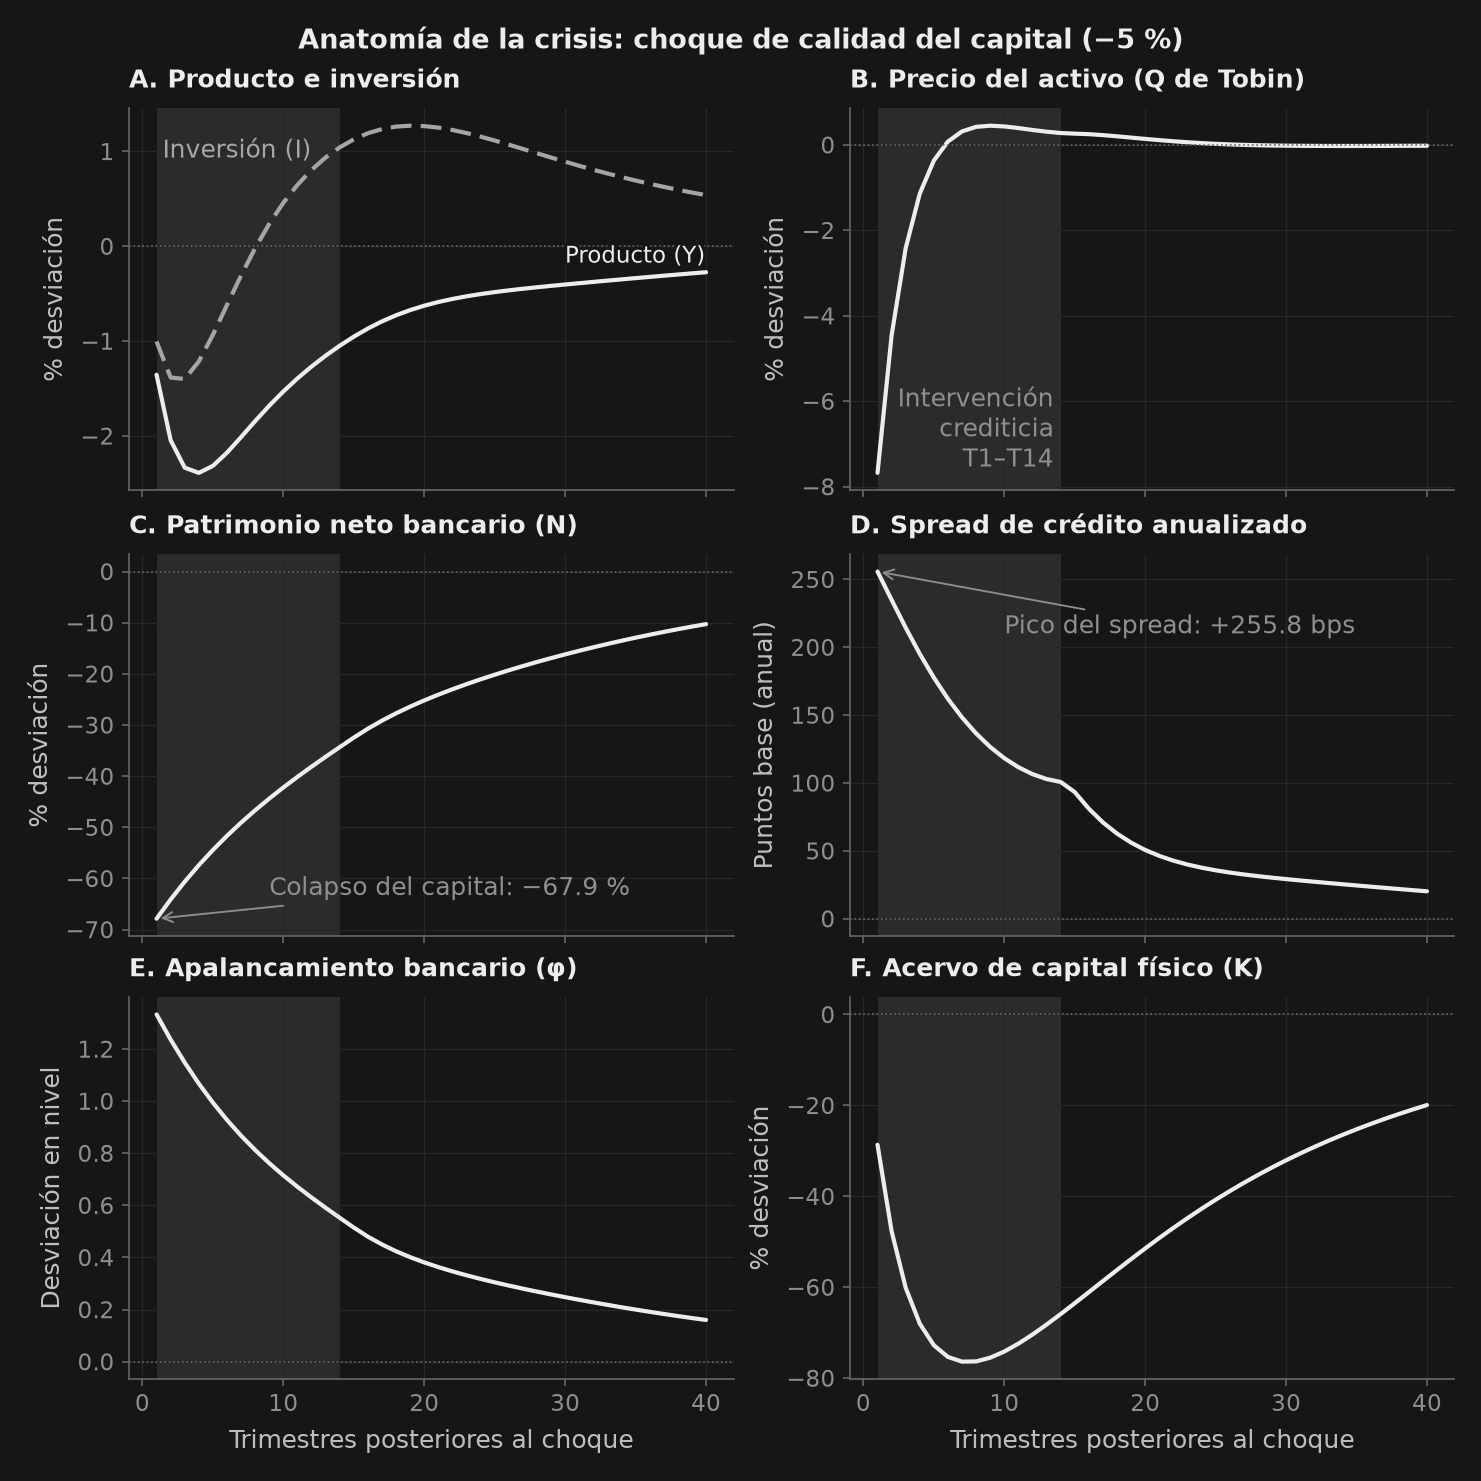

In [4]:
# ==============================================================================
# Visualización de Publicación en 6 Paneles de la Dinámica de Crisis
# ==============================================================================
fig, axes = _nbstyle.figura(3, 2, sharex=True)
t_horizon = np.arange(1, len(df_crisis) + 1)
bind_periods = res_crisis.binding_periods

# 1. Producto e Inversión
ax = axes[0, 0]
linea_y, = ax.plot(t_horizon, df_crisis["Y"] * 100.0, **_nbstyle.S1, label="Producto (Y)")
ax.plot(t_horizon, df_crisis["I"] * 100.0, **_nbstyle.S2)
ax.axhline(0.0, color=_nbstyle.SPINE, lw=0.8, ls=":")
_nbstyle.sombrear_recesion(ax, 1, bind_periods)
ax.set_title("A. Producto e inversión")
ax.set_ylabel("% desviación")
# La inversión sube en diagonal: su nombre va sobre el tramo ascendente, alineado a la derecha
ax.annotate(
    "Inversión (I)", xy=(12, df_crisis["I"].iloc[11] * 100.0),
    xytext=(0, 3), textcoords="offset points",
    ha="right", va="bottom", color=_nbstyle.S2["color"],
)
_nbstyle.etiquetar(ax, artistas=[linea_y], donde="fin")

# 2. Precio del Activo (Q de Tobin)
ax = axes[0, 1]
ax.plot(t_horizon, df_crisis["Q"] * 100.0, **_nbstyle.S1)
ax.axhline(0.0, color=_nbstyle.SPINE, lw=0.8, ls=":")
_nbstyle.sombrear_recesion(ax, 1, bind_periods)
ax.annotate(
    f"Intervención\ncrediticia\nT1–T{bind_periods}",
    xy=(bind_periods - 0.5, 0.04), xycoords=("data", "axes fraction"),
    ha="right", va="bottom", color=_nbstyle.NOTA,
)
ax.set_title("B. Precio del activo (Q de Tobin)")
ax.set_ylabel("% desviación")

# 3. Patrimonio Neto Bancario
ax = axes[1, 0]
ax.plot(t_horizon, df_crisis["N"] * 100.0, **_nbstyle.S1)
ax.axhline(0.0, color=_nbstyle.SPINE, lw=0.8, ls=":")
_nbstyle.sombrear_recesion(ax, 1, bind_periods)
ax.annotate(
    f"Colapso del capital: {df_crisis['N'].iloc[0]*100:.1f} %".replace("-", "−"),
    xy=(1, df_crisis["N"].iloc[0] * 100.0),
    xytext=(9, -62),
    arrowprops=_nbstyle.FLECHA,
    va="center",
    color=_nbstyle.NOTA,
)
ax.set_title("C. Patrimonio neto bancario (N)")
ax.set_ylabel("% desviación")

# 4. Spread de Crédito Anualizado
ax = axes[1, 1]
spread_ann = df_crisis["prem"] * 400.0 * 100.0
ax.plot(t_horizon, spread_ann, **_nbstyle.S1)
ax.axhline(0.0, color=_nbstyle.SPINE, lw=0.8, ls=":")
_nbstyle.sombrear_recesion(ax, 1, bind_periods)
ax.annotate(
    f"Pico del spread: +{spread_ann.iloc[0]:.1f} bps",
    xy=(1, spread_ann.iloc[0]),
    xytext=(10, 215),
    arrowprops=_nbstyle.FLECHA,
    va="center",
    color=_nbstyle.NOTA,
)
ax.set_title("D. Spread de crédito anualizado")
ax.set_ylabel("Puntos base (anual)")

# 5. Apalancamiento Bancario
ax = axes[2, 0]
ax.plot(t_horizon, df_crisis["phi"], **_nbstyle.S1)
ax.axhline(0.0, color=_nbstyle.SPINE, lw=0.8, ls=":")
_nbstyle.sombrear_recesion(ax, 1, bind_periods)
ax.set_title("E. Apalancamiento bancario (φ)")
ax.set_ylabel("Desviación en nivel")
ax.set_xlabel("Trimestres posteriores al choque")

# 6. Acervo de Capital Físico
ax = axes[2, 1]
ax.plot(t_horizon, df_crisis["K"] * 100.0, **_nbstyle.S1)
ax.axhline(0.0, color=_nbstyle.SPINE, lw=0.8, ls=":")
_nbstyle.sombrear_recesion(ax, 1, bind_periods)
ax.set_title("F. Acervo de capital físico (K)")
ax.set_ylabel("% desviación")
ax.set_xlabel("Trimestres posteriores al choque")

fig.suptitle("Anatomía de la crisis: choque de calidad del capital (−5 %)")
plt.show()


## 4. Política Crediticia No Convencional del Banco Central como Intermediario de Última Instancia

### 4.1 La Ineficacia de la Política Monetaria Convencional
En una crisis financiera sistémica, la política monetaria convencional (reducir la tasa de interés de política $R_{n,t}$ mediante la regla de Taylor) enfrenta límites severos. Incluso reduciendo la tasa a cero, el enorme incremento en el diferencial de crédito $\text{prem}_t = R_{k,t+1} - R_{t+1}$ mantiene prohibitivas las condiciones de financiamiento para las empresas productivas.

Dado que la distorsión radica en los balances deteriorados de los intermediarios privados, la relajación monetaria no se transmite eficazmente a la economía real.

### 4.2 Intervención Crediticia No Convencional: Compras Directas de Activos
Para eludir el canal bancario colapsado, Gertler y Karadi introducen la **intermediación crediticia directa del banco central**. La autoridad monetaria emite deuda pública (o depósitos remunerados) a los hogares y compra directamente derechos financieros sobre las empresas:
$$Q_t S_t = Q_t S_{b,t} + Q_t S_{g,t}$$
donde $Q_t S_{g,t}$ representa el crédito público suministrado por el banco central.

Sea $\psi_t$ la proporción de crédito total intermediada públicamente:
$$Q_t S_{g,t} = \psi_t Q_t S_t, \quad Q_t S_{b,t} = (1 - \psi_t) Q_t S_t$$

El banco central activa su programa de crédito según una regla de política con retroalimentación:
$$\psi_t = \nu_g \cdot \left( \mathbb{E}_t [R_{k,t+1} - R_{t+1}] - (R_k - R) \right) = \nu_g \cdot (\text{prem}_t - \text{prem}_{ss} - \text{prem}_{\text{trigger}})$$
cuando $\text{prem}_t > \text{prem}_{ss} + \text{prem}_{\text{trigger}}$, y $\psi_t = 0$ en caso contrario.

### 4.3 Mecanismo de Estabilización
A diferencia de los banqueros comerciales, el banco central:
1. No sufre fricciones de riesgo moral ni tentación de desvío: los depositantes confían plenamente en el respaldo fiscal del Estado.
2. No enfrenta riesgo de corridas bancarias ni límites endógenos de apalancamiento.

Al actuar como **intermediario de última instancia**, el banco central adquiere activos que la banca privada se ve forzada a liquidar. Esto sostiene los precios de los activos ($Q_t \uparrow$), comprime los diferenciales de crédito ($\text{prem}_t \downarrow$), mitiga la pérdida de capital bancario y previene un colapso generalizado de la economía.

Simulando contrafactuales de política a través de distintas intensidades de intervención...

TABLERO DE ESTABILIZACIÓN MACROECONÓMICA SEGÚN POLÍTICA CREDITICIA
     Régimen de Política Impacto Y (%) Valle Y (%) Pérdida Capital N (%) Spike Spread (bps) Pérdida Acum. Producto Trimestres Activos
Laissez-Faire (nu_g = 0)        -1.83%      -3.08%               -85.24%             +603.7                -37.39%                 11
    Moderada (nu_g = 10)        -1.35%      -2.39%               -67.88%             +255.8                -37.34%                 14
    Agresiva (nu_g = 20)        -1.26%      -2.25%               -64.73%             +192.9                -37.30%                 15


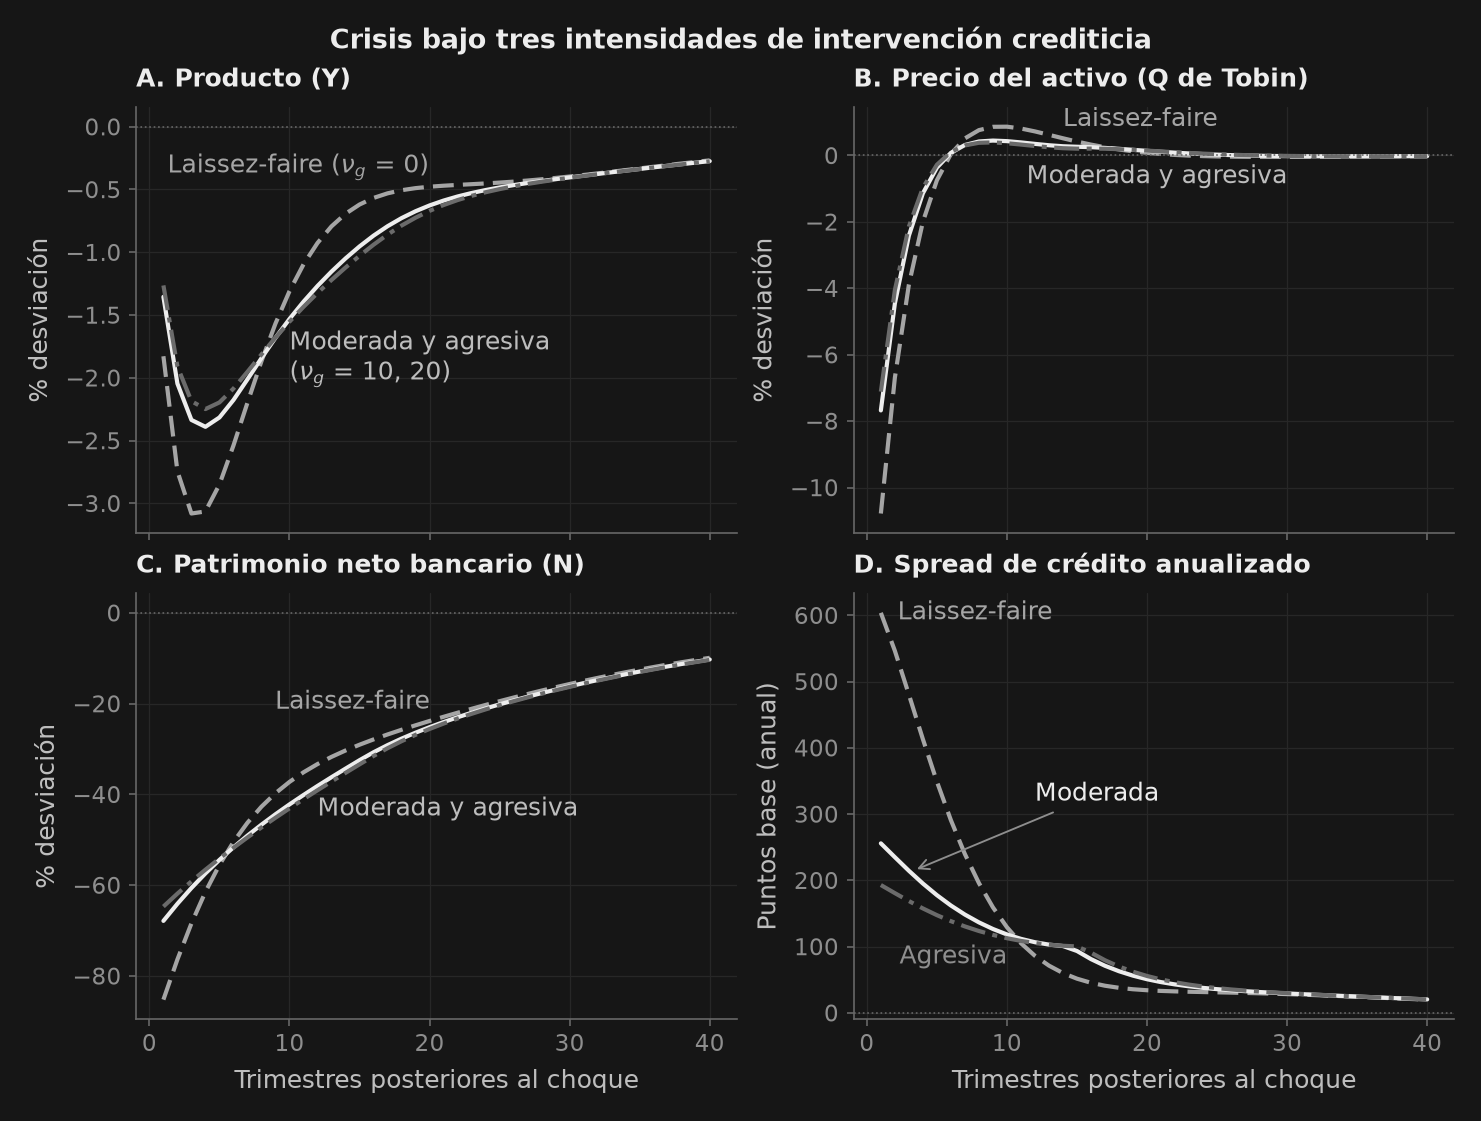

In [5]:
# ==============================================================================
# Experimento de Política Contrafactual: Laissez-Faire vs. Intervenciones Crediticias
# ==============================================================================
print("Simulando contrafactuales de política a través de distintas intensidades de intervención...")

# 1. Régimen A: Laissez-faire (nu_g = 0.0, sin intermediación del banco central)
res_no = solve_gertler_karadi(
    params={"nu_g": 0.0},
    shock_type="capital_quality",
    shock_size=-0.05,
    horizon=40,
    method="occbin",
)
df_no = res_no.to_frame()

# 2. Régimen B: Intervención Moderada (nu_g = 10.0, calibración canónica de Gertler-Karadi)
res_mod = solve_gertler_karadi(
    params={"nu_g": 10.0},
    shock_type="capital_quality",
    shock_size=-0.05,
    horizon=40,
    method="occbin",
)
df_mod = res_mod.to_frame()

# 3. Régimen C: Intervención Agresiva (nu_g = 20.0, fuerte respaldo público de crédito)
res_agg = solve_gertler_karadi(
    params={"nu_g": 20.0},
    shock_type="capital_quality",
    shock_size=-0.05,
    horizon=40,
    method="occbin",
)
df_agg = res_agg.to_frame()

# 4. Tabla comparativa de pérdidas y estabilización
loss_table = pd.DataFrame([
    {
        "Régimen de Política": "Laissez-Faire (nu_g = 0)",
        "Impacto Y (%)": f"{df_no['Y'].iloc[0]*100:.2f}%",
        "Valle Y (%)": f"{df_no['Y'].min()*100:.2f}%",
        "Pérdida Capital N (%)": f"{df_no['N'].iloc[0]*100:.2f}%",
        "Spike Spread (bps)": f"+{df_no['prem'].iloc[0]*400*100:.1f}",
        "Pérdida Acum. Producto": f"{df_no['Y'].sum()*100:.2f}%",
        "Trimestres Activos": f"{res_no.binding_periods}",
    },
    {
        "Régimen de Política": "Moderada (nu_g = 10)",
        "Impacto Y (%)": f"{df_mod['Y'].iloc[0]*100:.2f}%",
        "Valle Y (%)": f"{df_mod['Y'].min()*100:.2f}%",
        "Pérdida Capital N (%)": f"{df_mod['N'].iloc[0]*100:.2f}%",
        "Spike Spread (bps)": f"+{df_mod['prem'].iloc[0]*400*100:.1f}",
        "Pérdida Acum. Producto": f"{df_mod['Y'].sum()*100:.2f}%",
        "Trimestres Activos": f"{res_mod.binding_periods}",
    },
    {
        "Régimen de Política": "Agresiva (nu_g = 20)",
        "Impacto Y (%)": f"{df_agg['Y'].iloc[0]*100:.2f}%",
        "Valle Y (%)": f"{df_agg['Y'].min()*100:.2f}%",
        "Pérdida Capital N (%)": f"{df_agg['N'].iloc[0]*100:.2f}%",
        "Spike Spread (bps)": f"+{df_agg['prem'].iloc[0]*400*100:.1f}",
        "Pérdida Acum. Producto": f"{df_agg['Y'].sum()*100:.2f}%",
        "Trimestres Activos": f"{res_agg.binding_periods}",
    },
])

print("\n" + "=" * 86)
print("TABLERO DE ESTABILIZACIÓN MACROECONÓMICA SEGÚN POLÍTICA CREDITICIA")
print("=" * 86)
print(loss_table.to_string(index=False))
print("=" * 86)

# 5. Gráfico de Comparación Contrafactual
fig, axes = _nbstyle.figura(2, 2, sharex=True)
quarters = np.arange(1, 41)
regimenes = [
    ("Laissez-faire", df_no, _nbstyle.S2),
    ("Moderada", df_mod, _nbstyle.S1),
    ("Agresiva", df_agg, _nbstyle.S3),
]
paneles = [
    ("Y", 100.0, "A. Producto (Y)", "% desviación"),
    ("Q", 100.0, "B. Precio del activo (Q de Tobin)", "% desviación"),
    ("N", 100.0, "C. Patrimonio neto bancario (N)", "% desviación"),
    ("prem", 400.0 * 100.0, "D. Spread de crédito anualizado", "Puntos base (anual)"),
]
for ax, (var, escala, titulo, unidad) in zip(axes.flat, paneles):
    for nombre, df_r, estilo in regimenes:
        ax.plot(quarters, df_r[var] * escala, **estilo, label=nombre)
    ax.axhline(0.0, color=_nbstyle.SPINE, lw=0.8, ls=":")
    ax.set_title(titulo)
    ax.set_ylabel(unidad)
for ax in axes[1]:
    ax.set_xlabel("Trimestres posteriores al choque")


def nombrar(ax, texto, xy, ha, va, color, *, dy=3.0, desde=None):
    """El nombre de una serie junto a ella (sin leyenda).

    `xy` es el punto de la serie; con `desde`, el texto se escribe ahí y una
    flecha corta lo une con `xy`.
    """
    if desde is None:
        ax.annotate(texto, xy=xy, xytext=(0, {"bottom": dy, "top": -dy}.get(va, 0.0)),
                    textcoords="offset points", ha=ha, va=va, color=color)
    else:
        ax.annotate(texto, xy=xy, xytext=desde, textcoords="data", ha=ha, va=va,
                    color=color, arrowprops=_nbstyle.FLECHA)


def en(df_r, var, t, escala=100.0):
    """Valor de la serie `var` en el trimestre `t`, en la escala del panel."""
    return df_r[var].iloc[t - 1] * escala


# Las dos intervenciones casi coinciden salvo en el spread: en A–C se nombran juntas,
# en D cada una por separado, donde las tres líneas se separan
col_no, col_mod, col_agg, col_par = _nbstyle.S2["color"], _nbstyle.TINTA, _nbstyle.NOTA, _nbstyle.TEXTO
nombrar(axes[0, 0], r"Laissez-faire ($\nu_g$ = 0)", (20, en(df_no, "Y", 20)), "right", "bottom", col_no)
nombrar(axes[0, 0], "Moderada y agresiva\n" r"($\nu_g$ = 10, 20)", (10, en(df_agg, "Y", 10)), "left", "top", col_par)
nombrar(axes[0, 1], "Laissez-faire", (14, en(df_no, "Q", 14)), "left", "bottom", col_no)
nombrar(axes[0, 1], "Moderada y agresiva", (30, en(df_agg, "Q", 30)), "right", "top", col_par, dy=4.0)
nombrar(axes[1, 0], "Laissez-faire", (20, en(df_no, "N", 20)), "right", "bottom", col_no)
nombrar(axes[1, 0], "Moderada y agresiva", (12, en(df_agg, "N", 12)), "left", "top", col_par)
nombrar(axes[1, 1], "Laissez-faire", (2.2, en(df_no, "prem", 1, 40000.0)), "left", "center", col_no)
nombrar(axes[1, 1], "Moderada", (3.3, en(df_mod, "prem", 3, 40000.0)), "left", "center", col_mod, desde=(12, 330))
nombrar(axes[1, 1], "Agresiva", (10, en(df_agg, "prem", 10, 40000.0)), "right", "top", col_agg)

fig.suptitle("Crisis bajo tres intensidades de intervención crediticia")
plt.show()


## 5. Sensibilidad a Fricciones Estructurales: Estado de Derecho y Permanencia del Banquero

### 5.1 La Fracción Desviable $\lambda_b$ (Calidad Institucional y Garantías)
El parámetro $\lambda_b$ mide la severidad del problema de riesgo moral (o inversamente, la fortaleza del marco legal y la exigibilidad de garantías):
- Un **menor $\lambda_b$** refleja una mejor protección a acreedores: el banquero puede desviar menos fondos, por lo que los depositantes confían más en la institución.
- A partir de la condición de incentivos de estado estacionario, $\phi_{ss} = \frac{\eta}{\lambda_b - \nu}$, un menor $\lambda_b$ permite al sistema bancario operar con un **apalancamiento significativamente mayor** ($\phi_{ss} = 5.43$ con $\lambda = 0.25$ frente a $\phi_{ss} = 4.10$ con $\lambda = 0.381$).

**La Paradoja del Desarrollo Financiero**: Aunque un mayor apalancamiento aparenta elevar la eficiencia de la intermediación en tiempos normales, introduce una profunda fragilidad sistémica. Cuando se materializa un choque severo de calidad del capital, los bancos más apalancados experimentan una aniquilación patrimonial que supera el $100\%$, provocando una recesión macroeconómica mucho más profunda.

### 5.2 El Horizonte de Supervivencia del Banquero $\theta_b$ (Velocidad de Recapitalización)
El parámetro $\theta_b$ determina la permanencia esperada de los banqueros en el mercado:
$$\text{Tenencia Esperada} = \frac{1}{1 - \theta_b} \text{ trimestres}$$
- Si $\theta_b$ cae de $0.972$ (36 trimestres / 9 años) a $0.90$ (10 trimestres / 2.5 años), los banqueros se retiran y consumen su capital con rapidez.
- En consecuencia, el patrimonio neto $N_{ss}$ es mucho más escaso en el equilibrio, obligando al sistema a operar con un apalancamiento cercano a **$10\times$** ($\phi_{ss} \approx 9.70$).
- Con semejante apalancamiento, cualquier perturbación desata congelamientos crediticios extremos y una explosión del diferencial de crédito (más de $+2\,000$ bps en el impacto, frente a los $+603.7$ bps del laissez-faire de referencia).

Ejecutando barridos de sensibilidad en parámetros estructurales...


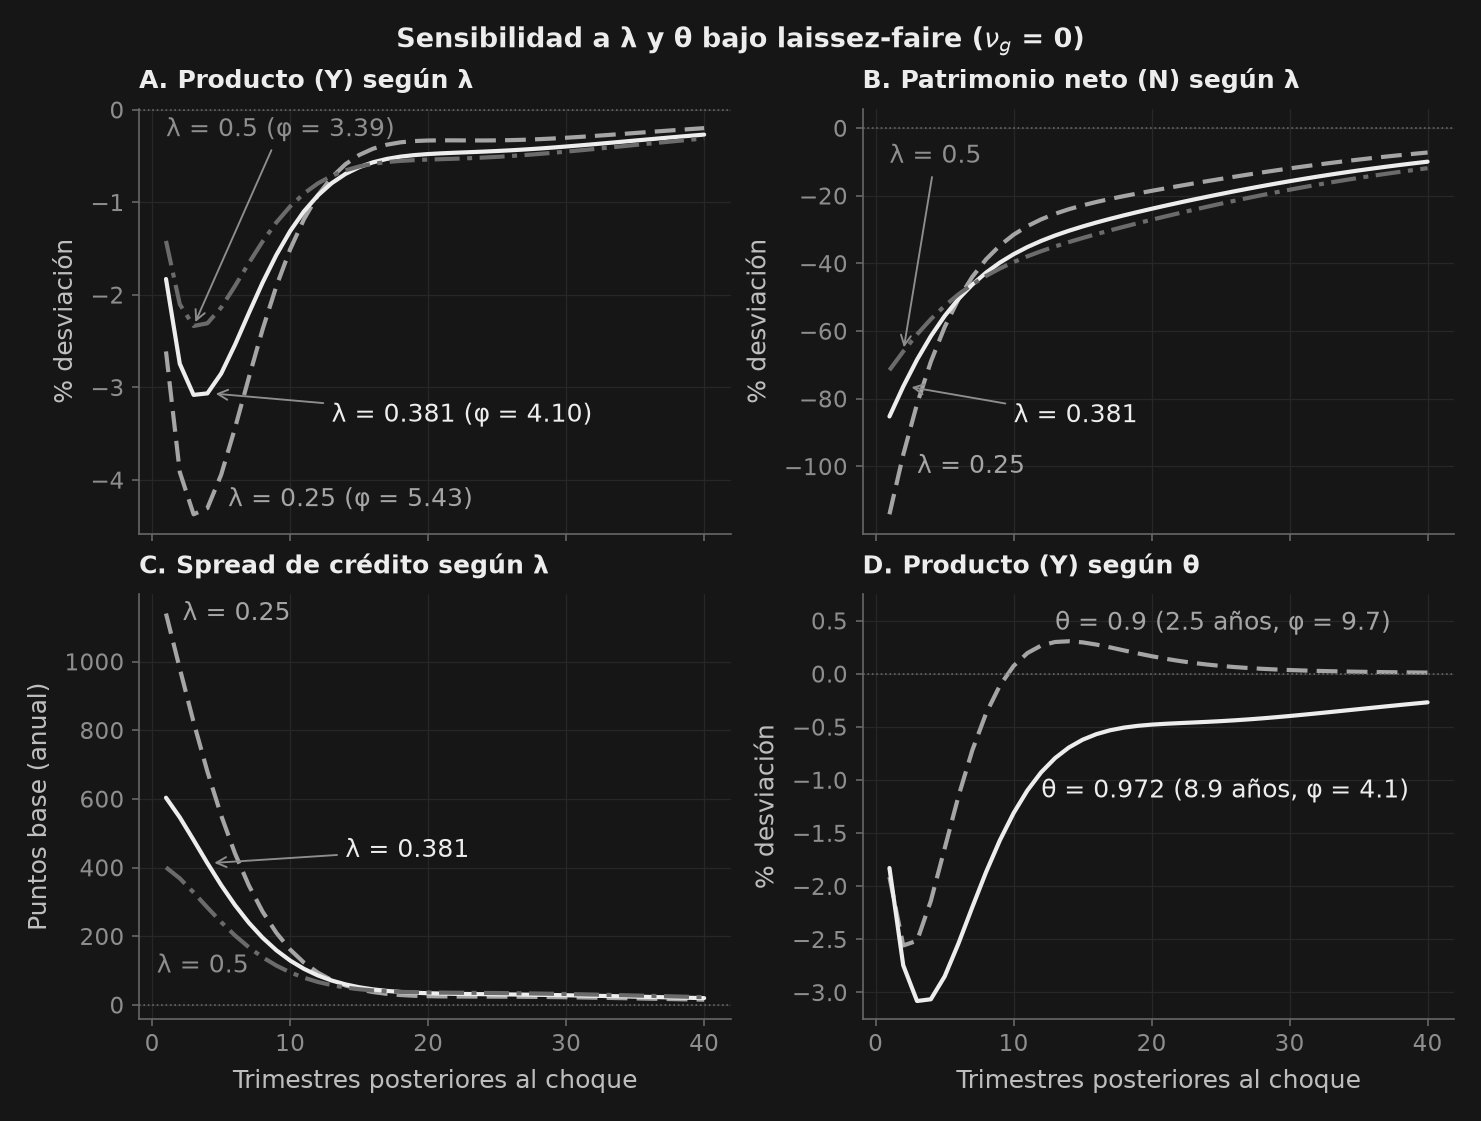

In [6]:
# ==============================================================================
# Barridos de Sensibilidad Estructural: Fracción Desviable (lambda) y Horizonte (theta)
# ==============================================================================
print("Ejecutando barridos de sensibilidad en parámetros estructurales...")

# Barrido 1: Fracción Desviable lambda_b en [0.25, 0.381, 0.50] bajo laissez-faire
lambda_vals = [0.25, 0.381, 0.50]
lambda_results = {}

for lam in lambda_vals:
    res_l = solve_gertler_karadi(
        params={"lambda_b": lam, "nu_g": 0.0},
        shock_type="capital_quality",
        shock_size=-0.05,
        horizon=40,
        method="occbin",
    )
    lambda_results[lam] = res_l

# Barrido 2: Horizonte de supervivencia theta_b en [0.90, 0.972] bajo laissez-faire
theta_vals = [0.90, 0.972]
theta_results = {}

for th in theta_vals:
    res_t = solve_gertler_karadi(
        params={"theta_b": th, "nu_g": 0.0},
        shock_type="capital_quality",
        shock_size=-0.05,
        horizon=40,
        method="occbin",
    )
    theta_results[th] = res_t

# Gráfico de sensibilidad de 4 paneles
fig, axes = _nbstyle.figura(2, 2, sharex=True)
quarters = np.arange(1, 41)
estilos_lam = [_nbstyle.S2, _nbstyle.S1, _nbstyle.S3]
paneles_lam = [
    ("Y", 100.0, "A. Producto (Y) según λ", "% desviación"),
    ("N", 100.0, "B. Patrimonio neto (N) según λ", "% desviación"),
    ("prem", 400.0 * 100.0, "C. Spread de crédito según λ", "Puntos base (anual)"),
]
df_lam = {lam: lambda_results[lam].to_frame() for lam in lambda_vals}
for ax, (var, escala, titulo, unidad) in zip(axes.flat, paneles_lam):
    for lam, estilo in zip(lambda_vals, estilos_lam):
        ax.plot(quarters, df_lam[lam][var] * escala, **estilo, label=f"λ = {lam}")
    ax.axhline(0.0, color=_nbstyle.SPINE, lw=0.8, ls=":")
    ax.set_title(titulo)
    ax.set_ylabel(unidad)

# Panel D: Producto según theta_b
ax = axes[1, 1]
estilos_th = [_nbstyle.S2, _nbstyle.S1]
df_th = {th: theta_results[th].to_frame() for th in theta_vals}
for th, estilo in zip(theta_vals, estilos_th):
    ax.plot(quarters, df_th[th]["Y"] * 100.0, **estilo, label=f"θ = {th}")
ax.axhline(0.0, color=_nbstyle.SPINE, lw=0.8, ls=":")
ax.set_title("D. Producto (Y) según θ")
ax.set_ylabel("% desviación")
for ax in axes[1]:
    ax.set_xlabel("Trimestres posteriores al choque")

# Nombres junto a las líneas (nombrar y en, definidos en la sección 4): las tres λ sólo se
# separan en el valle, así que la intermedia se señala con una flecha corta
phi = {lam: lambda_results[lam].steady_state["phi_ss"] for lam in lambda_vals}
col_lam = [_nbstyle.S2["color"], _nbstyle.TINTA, _nbstyle.NOTA]
nombrar(axes[0, 0], f"λ = 0.25 (φ = {phi[0.25]:.2f})", (5.5, en(df_lam[0.25], "Y", 5)), "left", "top", col_lam[0], dy=6.0)
nombrar(axes[0, 0], f"λ = 0.381 (φ = {phi[0.381]:.2f})", (4.3, en(df_lam[0.381], "Y", 4)), "left", "center", col_lam[1], desde=(13, -3.3))
nombrar(axes[0, 0], f"λ = 0.5 (φ = {phi[0.5]:.2f})", (3, en(df_lam[0.5], "Y", 3)), "left", "bottom", col_lam[2], desde=(1, -0.35))
nombrar(axes[0, 1], "λ = 0.25", (3, -100), "left", "center", col_lam[0])
nombrar(axes[0, 1], "λ = 0.381", (2.3, en(df_lam[0.381], "N", 2)), "left", "center", col_lam[1], desde=(10, -85))
nombrar(axes[0, 1], "λ = 0.5", (2, en(df_lam[0.5], "N", 2)), "left", "bottom", col_lam[2], desde=(1, -12))
nombrar(axes[1, 0], "λ = 0.25", (2.2, en(df_lam[0.25], "prem", 1, 40000.0)), "left", "center", col_lam[0])
nombrar(axes[1, 0], "λ = 0.381", (4.2, en(df_lam[0.381], "prem", 4, 40000.0)), "left", "center", col_lam[1], desde=(14, 450))
nombrar(axes[1, 0], "λ = 0.5", (7, en(df_lam[0.5], "prem", 7, 40000.0)), "right", "top", col_lam[2])
axes[1, 1].set_ylim(top=0.75)          # sitio para el nombre sobre la joroba de θ = 0.9
for th, color, (x, va) in zip(theta_vals, [col_lam[0], col_lam[1]], [(13, "bottom"), (12, "top")]):
    tenure_yrs = (1.0 / (1.0 - th)) / 4.0
    phi_th = theta_results[th].steady_state["phi_ss"]
    nombrar(axes[1, 1], f"θ = {th} ({tenure_yrs:.1f} años, φ = {phi_th:.1f})", (x, en(df_th[th], "Y", x)), "left", va, color)

fig.suptitle(r"Sensibilidad a λ y θ bajo laissez-faire ($\nu_g$ = 0)")
plt.show()


## 6. Desafíos Analíticos Guiados para Macroeconomistas

Para profundizar en la comprensión de las fricciones macrofinancieras, resuelve los siguientes retos analíticos:

### Reto 1: Transmisión de Choques Monetarios bajo Fricciones Financieras
En modelos Nuevo Keynesianos estándar sin banca, una subida imprevista de la tasa de política monetaria ($R_{n,t} \uparrow$) contrae el producto principalmente mediante la sustitución intertemporal del consumo. En el modelo de Gertler-Karadi, tasas más altas también encarecen el fondeo bancario, reduciendo el multiplicador $\eta_t$ y contrayendo la capacidad de apalancamiento.
- **Tarea**: Simula un choque monetario contractivo imprevisto de $+25$ bps (`shock_type='monetary'`, `shock_size=0.0025`).
- **Pregunta Analítica**: ¿El acelerador financiero amplifica o atenúa la contracción de la inversión y el producto frente a un modelo sin bancos?

### Reto 2: Costos Fiscales y Distorsiones de la Intermediación Pública de Crédito
En la calibración base, el crédito del banco central no genera pérdidas directas de eficiencia. En la práctica, la asignación pública de crédito puede enfrentar distorsiones de información, interferencia política o costos administrativos $\tau \cdot \frac{\psi_t^2}{2}$.
- **Pregunta Analítica**: Si el crédito público genera un costo convexo $\tau = 0.05$, ¿cómo altera esto la intensidad de intervención óptima $\nu_g^*$? ¿Cuál es el compromiso económico entre evitar ventas forzosas privadas y minimizar distorsiones públicas?

### Reto 3: Regulación Macroprudencial Ex-Ante vs. Rescates del Banco Central Ex-Post
Gertler y Karadi analizan tanto compras ex-post de activos (`constraint_type='credit_policy'`) como topes regulatorios ex-ante al apalancamiento (`constraint_type='leverage_cap'`).
- **Pregunta Analítica**: ¿Por qué imponer un límite de apalancamiento ex-ante ($Q_t S_{b,t} \le \bar{\phi} N_t$) reduce la gravedad de las crisis futuras, aun cuando funcione como un gravamen distorsivo durante fases expansivas?

In [7]:
# ==============================================================================
# Suite Automatizada de Verificación Autocontenida
# ==============================================================================
print("Ejecutando suite automatizada de verificación para Gertler-Karadi (2011)...")

# 1. Determinancia y Estabilidad de Punto de Silla
assert m_gk.is_determinate, "Fallo: el modelo debe satisfacer la determinancia de Blanchard-Kahn"
assert m_gk.solution.eu == (1, 1), f"Fallo: eu debe ser (1, 1), obtenido {m_gk.solution.eu}"

# 2. Invariantes de Calibración en Estado Estacionario
assert 3.90 < m_gk.steady_state["phi"] < 4.30, (
    f"Fallo: el apalancamiento de estado estacionario debe ser ~4.10, obtenido {m_gk.steady_state['phi']:.4f}"
)
assert 0.80 < m_gk.steady_state["prem"] * 400.0 < 1.20, (
    f"Fallo: el spread anualizado debe ser ~1.00%, obtenido {m_gk.steady_state['prem']*400.0:.4f}%"
)
assert np.isclose(m_gk.steady_state["Q"], 1.00, atol=1e-3), (
    f"Fallo: la Q de Tobin en estado estacionario debe ser 1.0, obtenido {m_gk.steady_state['Q']}"
)

# 3. Dinámica de Crisis Financiera (Laissez-Faire)
assert df_no["Q"].iloc[0] < -0.05, (
    f"Fallo: el precio del activo Q debe caer al menos -5%, obtenido {df_no['Q'].iloc[0]*100:.2f}%"
)
assert df_no["prem"].iloc[0] > 0.010, (
    f"Fallo: el spread de crédito debe ampliarse contracíclicamente (>100 bps), obtenido {df_no['prem'].iloc[0]*400*100:.1f} bps"
)
assert df_no["N"].iloc[0] < -0.50, (
    f"Fallo: el patrimonio bancario debe colapsar más de 50%, obtenido {df_no['N'].iloc[0]*100:.2f}%"
)
assert abs(df_no["N"].iloc[0]) > 5.0 * abs(df_no["Y"].iloc[0]), (
    f"Fallo: la aniquilación del capital debe exceder 5 veces la caída del producto, "
    f"obtenido {abs(df_no['N'].iloc[0])/abs(df_no['Y'].iloc[0]):.1f}x"
)

# 4. Invariantes de Estabilización de Política del Banco Central
# La política crediticia amortigua estrictamente la caída del producto
assert abs(df_mod["Y"].iloc[0]) < abs(df_no["Y"].iloc[0]), (
    f"Fallo: la política crediticia moderada debe atenuar la caída inicial del producto"
)
# La política crediticia protege el patrimonio bancario
assert abs(df_mod["N"].iloc[0]) < abs(df_no["N"].iloc[0]), (
    f"Fallo: la política crediticia debe amortiguar la pérdida de capital bancario"
)
# La política crediticia comprime el spread
assert df_mod["prem"].iloc[0] < df_no["prem"].iloc[0], (
    f"Fallo: la política crediticia debe comprimir el spread de crédito"
)
# Una política más agresiva proporciona mayor o igual estabilización inicial
assert abs(df_agg["Y"].iloc[0]) <= abs(df_mod["Y"].iloc[0]), (
    f"Fallo: la política agresiva debe estabilizar igual o más que la moderada"
)

# 5. Invariantes de Sensibilidad Estructural
# Menor lambda permite mayor apalancamiento de estado estacionario
ss_phi_low_lam = lambda_results[0.25].steady_state["phi_ss"]
ss_phi_base = m_gk.steady_state["phi"]
assert ss_phi_low_lam > ss_phi_base, (
    f"Fallo: un menor lambda debe permitir un mayor apalancamiento en estado estacionario, "
    f"obtenido {ss_phi_low_lam:.2f} vs {ss_phi_base:.2f}"
)

# Mayor apalancamiento amplifica el colapso del capital
n_wipeout_low_lam = lambda_results[0.25].to_frame()["N"].iloc[0]
n_wipeout_base = df_no["N"].iloc[0]
assert abs(n_wipeout_low_lam) > abs(n_wipeout_base), (
    f"Fallo: un mayor apalancamiento debe amplificar la aniquilación del capital bancario, "
    f"obtenido {n_wipeout_low_lam*100:.1f}% vs {n_wipeout_base*100:.1f}%"
)

print("=" * 80)
print("¡TODAS LAS ASERCIONES DE VERIFICACIÓN AUTOMATIZADA DE GERTLER-KARADI PASARON (10/10)!")
print("=" * 80)

Ejecutando suite automatizada de verificación para Gertler-Karadi (2011)...
¡TODAS LAS ASERCIONES DE VERIFICACIÓN AUTOMATIZADA DE GERTLER-KARADI PASARON (10/10)!
